In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_path = "/content/drive/MyDrive/customer_shopping_data.csv"

In [ ]:
import pandas as pd

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(99457, 10)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
SEED = 42

# Deneme modu:
# "sample40k" -> 40.000 satır
# "all"       -> tüm veri
RUN_MODE = "sample40k"   # sonra "all" yapacağız

SAMPLE_N = 40000

if RUN_MODE == "sample40k":
    df = df.sample(n=SAMPLE_N, random_state=SEED).copy()
    print("✅ SAMPLE MODE:", df.shape)
else:
    print("✅ FULL MODE:", df.shape)


✅ SAMPLE MODE: (40000, 10)


In [ ]:
# Null sayıları
df.isna().sum().sort_values(ascending=False)

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [ ]:
#kategorik sütunlardaki string nan,null değerlerini tespit ettik
cat_cols = ["invoice_no","customer_id","gender","category","payment_method","shopping_mall"]

for c in cat_cols:
    # string'e çevirip trimle
    s = df[c].astype(str)
    empty_like = (s.str.strip() == "") | (s.str.strip().str.lower().isin(["nan","none","null"]))
    print(c, "-> empty-like:", int(empty_like.sum()))


invoice_no -> empty-like: 0
customer_id -> empty-like: 0
gender -> empty-like: 0
category -> empty-like: 0
payment_method -> empty-like: 0
shopping_mall -> empty-like: 0


In [ ]:
#string olan tarih bilgisini gerçek tarih formatına çevirdik
import pandas as pd

# 1) invoice_date'ı datetime'a çevir
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True, errors="coerce")

# 2) hem dtype hem NaT kontrolü
print("dtype:", df["invoice_date"].dtype)
print("NaT sayısı:", df["invoice_date"].isna().sum())


dtype: datetime64[ns]
NaT sayısı: 0


In [ ]:
# kullanılacak sayısal özelliklerin veri tiplerini kontrol ettik.
num_cols = ["age","quantity","price"]
df[num_cols].dtypes

"""ilk deneme"""

,0
age,int64
quantity,int64
price,float64


In [ ]:
#sayısal olması gereken ama olmayan sütunlar sayısala çevrilir.çevrilmeyen satırlar silinir

num_cols = ["age", "quantity", "price"]

print("ÖNCE:")
print(df[num_cols].dtypes)

# Garanti olsun diye sayısala zorluyoruz
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("\nSONRA:")
print(df[num_cols].dtypes)

print("\nBu işlemden sonra oluşan NaN var mı?")
print(df[num_cols].isna().sum())

if df[num_cols].isna().sum().sum() > 0:
    print("Uyarı: Sayısala dönüşmeyen satırlar var, düşürüyorum.")
    df = df.dropna(subset=num_cols).copy()

ÖNCE:
age           int64
quantity      int64
price       float64
dtype: object

SONRA:
age           int64
quantity      int64
price       float64
dtype: object

Bu işlemden sonra oluşan NaN var mı?
age         0
quantity    0
price       0
dtype: int64


In [ ]:
#sayısal olarak mantıksız değer içeren satırlar silinir 
bad_mask = (df["age"]<=0) | (df["quantity"]<=0) | (df["price"]<=0)
print("Bozuk satır sayısı:", bad_mask.sum())

if bad_mask.sum() > 0:
    df = df.loc[~bad_mask].copy()
    print("Bozuk satırlar düşürüldü. Yeni shape:", df.shape)


Bozuk satır sayısı: 0


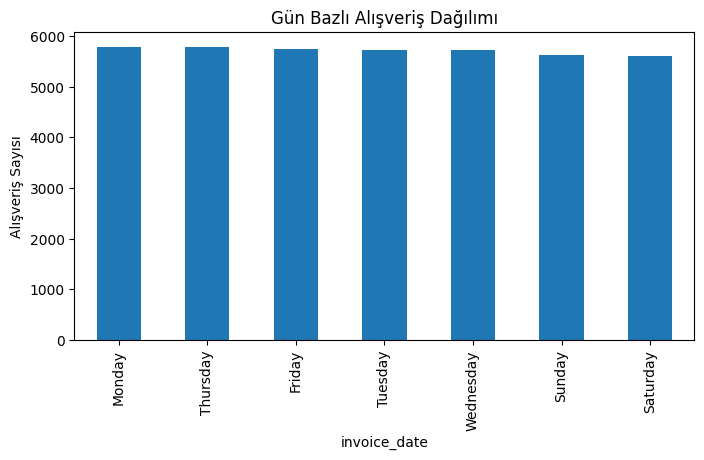

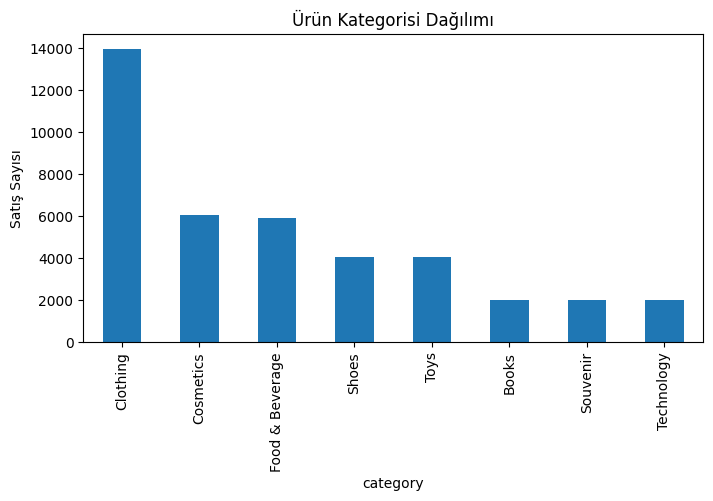

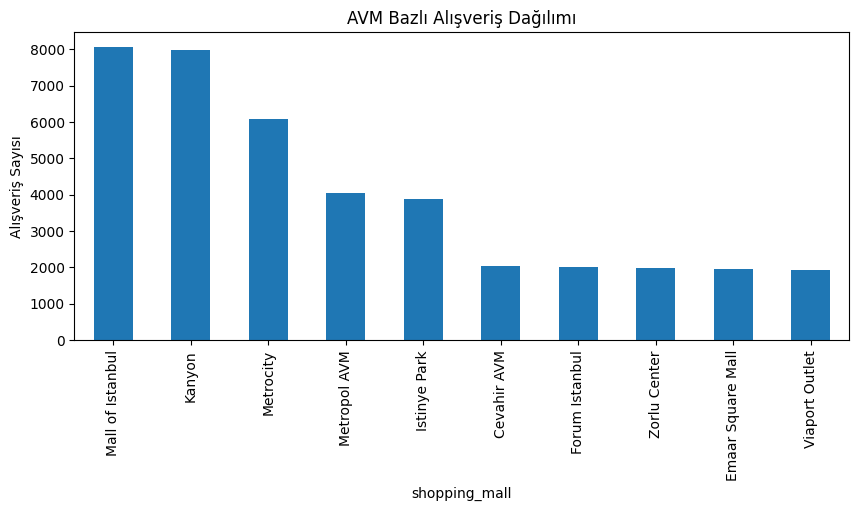

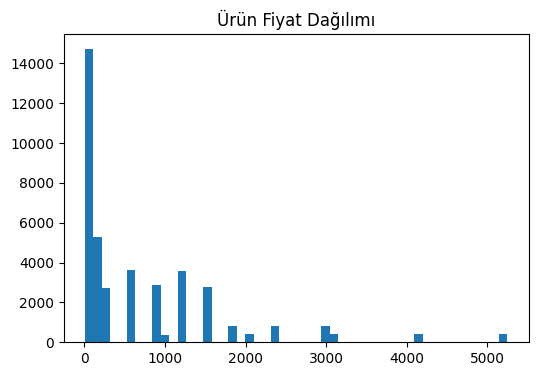

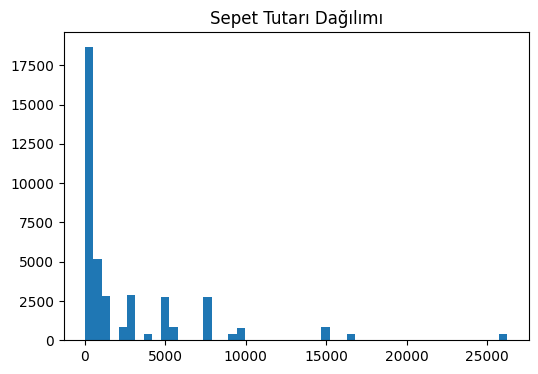

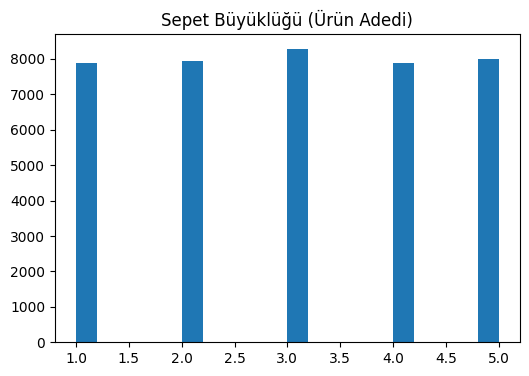

In [ ]:
#EDA bölümü ile grafik analizi yapılır
import matplotlib.pyplot as plt

day_counts = df["invoice_date"].dt.day_name().value_counts()

plt.figure(figsize=(8,4))
day_counts.plot(kind="bar")
plt.title("Gün Bazlı Alışveriş Dağılımı")
plt.ylabel("Alışveriş Sayısı")
plt.show()

category_counts = df["category"].value_counts()

plt.figure(figsize=(8,4))
category_counts.plot(kind="bar")
plt.title("Ürün Kategorisi Dağılımı")
plt.ylabel("Satış Sayısı")
plt.show()

mall_counts = df["shopping_mall"].value_counts()

plt.figure(figsize=(10,4))
mall_counts.plot(kind="bar")
plt.title("AVM Bazlı Alışveriş Dağılımı")
plt.ylabel("Alışveriş Sayısı")
plt.show()

df["basket_total"] = df["quantity"] * df["price"]

plt.figure(figsize=(6,4))
plt.hist(df["price"], bins=50)
plt.title("Ürün Fiyat Dağılımı")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["basket_total"], bins=50)
plt.title("Sepet Tutarı Dağılımı")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["quantity"], bins=20)
plt.title("Sepet Büyüklüğü (Ürün Adedi)")
plt.show()



In [ ]:
#feature engineering ile haftasonu özelliğini türettik
import pandas as pd
import numpy as np

df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True, errors="coerce")
df["is_weekend"] = df["invoice_date"].dt.dayofweek.isin([5, 6]).astype(int)

df[["invoice_date", "is_weekend"]].head()

,invoice_date,is_weekend
65475,2021-05-14,0
96548,2022-09-09,0
33949,2021-04-01,0
58198,2022-08-03,0
71781,2021-04-15,0


In [ ]:
#tarih dönüşümü sonrası tarih bilgisi bozuk olan satırları sildik
# invoice_date parse sonrası bozuk tarih kontrolü (NaT)
nat_count = df["invoice_date"].isna().sum()
nat_pct = nat_count / len(df) * 100
print("invoice_date NaT (parse edilemeyen):", nat_count, f"(%{nat_pct:.4f})")

# Eğer NaT varsa (genelde 0 çıkar), azsa satır düşmek en temiz yöntem
if nat_count > 0:
    before = len(df)
    df = df.dropna(subset=["invoice_date"]).copy()
    print("Dropped rows due to NaT:", before - len(df))


invoice_date NaT (parse edilemeyen): 0 (%0.0000)


In [ ]:
# invoice_date sütununu kullanarak alışverişin zamansal bağlamını daha ayrıntılı olacak yeni özellikler ürettik.
df["day_name"] = df["invoice_date"].dt.day_name()
df["day_of_week"] = df["invoice_date"].dt.dayofweek
df["month"] = df["invoice_date"].dt.month

df[["day_name", "day_of_week", "month"]].head()

,day_name,day_of_week,month
65475,Friday,4,5
96548,Friday,4,9
33949,Thursday,3,4
58198,Wednesday,2,8
71781,Thursday,3,4


In [ ]:
#modelin neyi tahmin edeceği(target) ve hangi verilerle tahmin yapacağı(features) ayrıldı
#Bu projede amaç: müşterinin satın aldığı ürün kategorisini tahmin etmek.
target_col = "category"

# customer_id DROP ETME! (group split için lazım)
# basket_total modelde KULLANILMAYACAK (sadece EDA içindi)
drop_cols = [
    "invoice_no",
    "invoice_date",
    "day_name",
    "day_of_week",
    "month",
    "basket_total"
]

X = df.drop(columns=[target_col] + drop_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y unique classes:", y.nunique())

# Güvenlik kontrolleri (çok önemli)
print("customer_id X'te var mı? ->", "customer_id" in X.columns)
print("basket_total X'te var mı? ->", "basket_total" in X.columns)
print("category X'te var mı? ->", "category" in X.columns)

X.head()


X shape: (40000, 8)
y unique classes: 8
customer_id X'te var mı? -> True
basket_total X'te var mı? -> False
category X'te var mı? -> False


,customer_id,gender,age,quantity,price,payment_method,shopping_mall,is_weekend
65475,C971218,Female,56,4,20.92,Cash,Kanyon,0
96548,C949846,Male,22,5,26.15,Cash,Metrocity,0
33949,C440398,Female,53,4,20.92,Debit Card,Kanyon,0
58198,C113971,Female,65,5,26.15,Credit Card,Cevahir AVM,0
71781,C529879,Female,51,4,2400.68,Credit Card,Metropol AVM,0


In [ ]:
cat_cols = ["shopping_mall", "gender", "payment_method"]
num_cols = ["age", "quantity", "price", "is_weekend"]

# customer_id ayrı: modele sokma, sadece groups için
id_col = "customer_id"

print("Categorical:", cat_cols)
print("Numerical:", num_cols)
print("ID col:", id_col)
print("\nX columns:", list(X.columns))


Categorical: ['shopping_mall', 'gender', 'payment_method']
Numerical: ['age', 'quantity', 'price', 'is_weekend']
ID col: customer_id

X columns: ['customer_id', 'gender', 'age', 'quantity', 'price', 'payment_method', 'shopping_mall', 'is_weekend']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded y sample:", y_enc[:10])

Classes: ['Books', 'Clothing', 'Cosmetics', 'Food & Beverage', 'Shoes', 'Souvenir', 'Technology', 'Toys']
Encoded y sample: [3 3 3 3 4 7 1 0 1 6]


In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

SEED = 42

# Güvenlik kontrolleri (leakage engeli)
assert "customer_id" in X.columns, "X içinde customer_id yok! Hücre 14'ü kontrol et."
assert "basket_total" not in X.columns, "basket_total X'e girmiş! Hücre 14'te drop etmelisin."
assert "category" not in X.columns, "category X'e girmiş! Leakage var."

groups = X["customer_id"]

# MODELE GİRECEK ÖZELLİKLER (customer_id hariç)
X_model = X.drop(columns=["customer_id"]).copy()

# 80/20 Group Split (müşteri sızıntısını engeller)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X_model, y_enc, groups=groups))

X_train = X_model.iloc[train_idx].copy()
y_train = y_enc[train_idx]

X_test  = X_model.iloc[test_idx].copy()
y_test  = y_enc[test_idx]

print("Group Split -> Train:", X_train.shape, "Test:", X_test.shape)

# müşteri çakışması kontrol
train_ids = set(groups.iloc[train_idx])
test_ids  = set(groups.iloc[test_idx])
print("Train∩Test müşteri:", len(train_ids & test_ids))  # 0 olmalı

# preprocess fit sadece train
X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

def to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

X_train_d = to_dense(X_train_p)
X_test_d  = to_dense(X_test_p)

print("Dense shapes ->", X_train_d.shape, X_test_d.shape)


Group Split -> Train: (32000, 7) Test: (8000, 7)
Train∩Test müşteri: 0
Dense shapes -> (32000, 19) (8000, 19)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_d.shape[1]   # 19
num_classes = len(le.classes_)   # 8

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,928 (54.41 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("class_weight:", class_weight_dict)

# Epoch / Batch otomatik ayar (dataset büyüklüğüne göre)
N = X_train_d.shape[0]

# batch: 40k için 256 iyi, full veri için 512 daha stabil
if N < 50000:
    BATCH = 256
    EPOCHS = 40
else:
    BATCH = 512
    EPOCHS = 30

print(f"Training config -> N={N}, batch={BATCH}, epochs={EPOCHS}")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history = model.fit(
    X_train_d, y_train,
    validation_split=0.10,       # ✅ Train içinden %10 val
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


class_weight: {0: np.float64(2.473716759431045), 1: np.float64(0.36114120621162876), 2: np.float64(0.8237232289950577), 3: np.float64(0.8438818565400844), 4: np.float64(1.2360939431396787), 5: np.float64(2.5316455696202533), 6: np.float64(2.4554941682013505), 7: np.float64(1.224739742804654)}
Training config -> N=32000, batch=256, epochs=40
Epoch 1/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1744 - loss: 2.1997 - val_accuracy: 0.3841 - val_loss: 1.6865 - learning_rate: 0.0010
Epoch 2/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4183 - loss: 1.4274 - val_accuracy: 0.5775 - val_loss: 1.0690 - learning_rate: 0.0010
Epoch 3/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5608 - loss: 1.1848 - val_accuracy: 0.6153 - val_loss: 0.8690 - learning_rate: 0.0010
Epoch 4/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6509 - loss: 1.0063 - val_accuracy: 0.6400 - val_loss: 0.9845 - learning_rate: 0.0010
Epoch 5/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/

In [ ]:
print("📌 FINAL TRAIN METRICS")
print(f"Train Accuracy (last): {history.history['accuracy'][-1]:.4f}")
print(f"Train Loss     (last): {history.history['loss'][-1]:.4f}")

print("\n📌 FINAL VALIDATION METRICS")
print(f"Val Accuracy (last): {history.history['val_accuracy'][-1]:.4f}")
print(f"Val Loss     (last): {history.history['val_loss'][-1]:.4f}")


📌 FINAL TRAIN METRICS
Train Accuracy (last): 0.8967
Train Loss     (last): 0.2558

📌 FINAL VALIDATION METRICS
Val Accuracy (last): 0.9981
Val Loss     (last): 0.1223


In [ ]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"✅ Best Epoch (min val_loss): {best_epoch}")
print(f"Best Val Loss: {min(history.history['val_loss']):.4f}")


✅ Best Epoch (min val_loss): 40
Best Val Loss: 0.1223


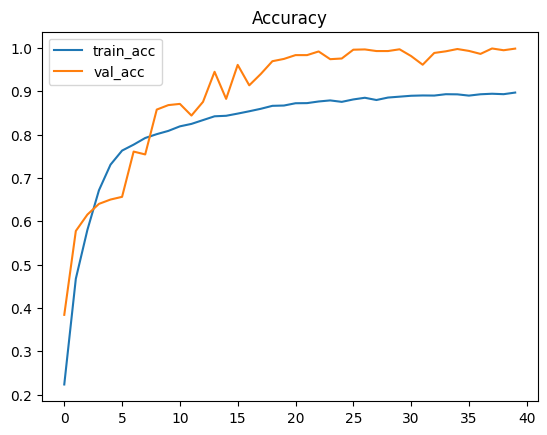

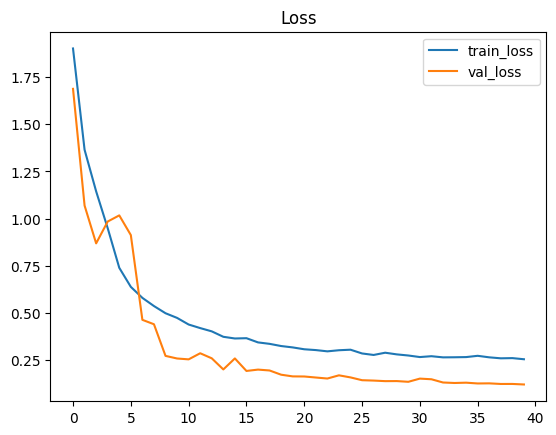

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()
#overfitting kontrol


Logistic Regression Test Accuracy: 0.803375

Classification Report (TEST):
                 precision    recall  f1-score   support

          Books       0.00      0.00      0.00       383
       Clothing       1.00      1.00      1.00      2891
      Cosmetics       0.61      1.00      0.76      1206
Food & Beverage       0.59      1.00      0.74      1152
          Shoes       1.00      1.00      1.00       808
       Souvenir       0.00      0.00      0.00       420
     Technology       1.00      1.00      1.00       370
           Toys       0.00      0.00      0.00       770

       accuracy                           0.80      8000
      macro avg       0.52      0.62      0.56      8000
   weighted avg       0.69      0.80      0.73      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


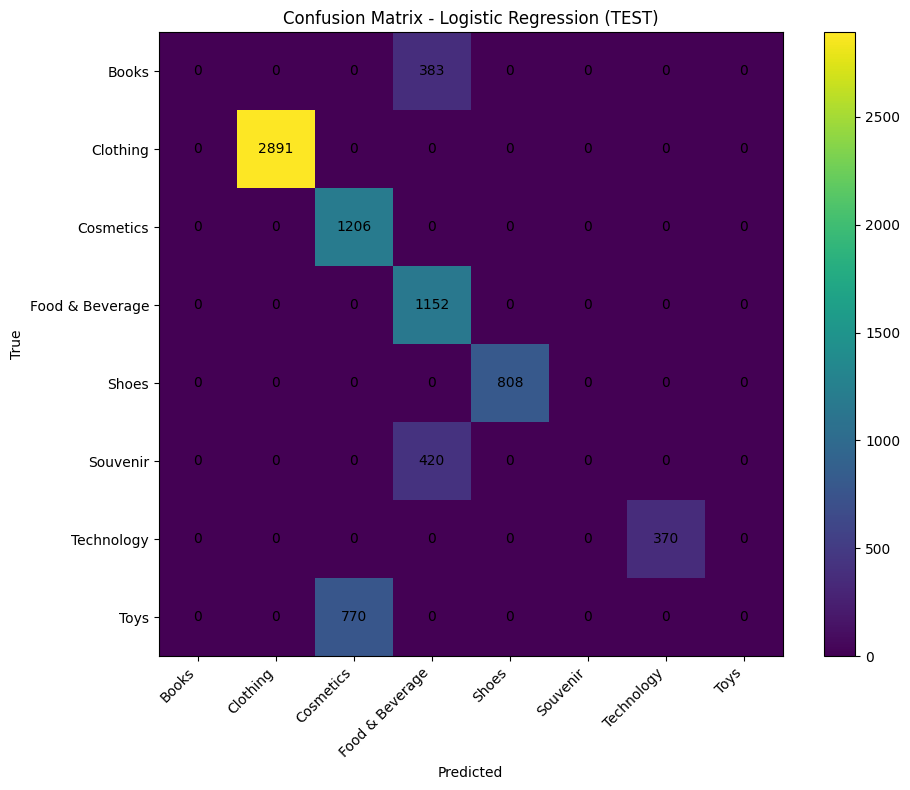


📌 BASELINE COMPARISON
Neural Network Val Acc : 0.9981
Logistic Reg. Val Acc : 0.8154


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

logreg = LogisticRegression(max_iter=2000, n_jobs=-1)
logreg.fit(X_train_d, y_train)

y_test_pred_lr = logreg.predict(X_test_d)

print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("\nClassification Report (TEST):")
print(classification_report(y_test, y_test_pred_lr, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Logistic Regression (TEST)")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print("\n📌 BASELINE COMPARISON")
print(f"Neural Network Val Acc : {history.history['val_accuracy'][-1]:.4f}")
print(f"Logistic Reg. Val Acc : {accuracy_score(y_val, y_val_pred_lr):.4f}")


In [ ]:
print("Predict öncesi y_test_pred var mı?:", "y_test_pred" in globals())
if "y_test_pred" in globals():
    print("Predict öncesi y_test_pred ilk 10:", y_test_pred[:10])
    del y_test_pred
    print("Eski y_test_pred silindi ✅")


Predict öncesi y_test_pred var mı?: True
Predict öncesi y_test_pred ilk 10: [3 6 4 1 7 2 5 5 3 6]
Eski y_test_pred silindi ✅


In [ ]:
import numpy as np

# Test setinde olasılıklar
y_test_proba = model.predict(X_test_d)

# Sınıf tahminleri (0..7)
y_test_pred = np.argmax(y_test_proba, axis=1)

print("y_test shape:", y_test.shape)
print("y_test_pred shape:", y_test_pred.shape)
print("İlk 10 gerçek:", y_test[:10])
print("İlk 10 tahmin:", y_test_pred[:10])

print("Prob row sum (ilk 3):", np.sum(y_test_proba[:3], axis=1))


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
y_test shape: (8000,)
y_test_pred shape: (8000,)
İlk 10 gerçek: [1 0 2 7 3 1 1 2 2 5]
İlk 10 tahmin: [1 0 2 7 3 1 1 2 2 5]
Prob row sum (ilk 3): [1.        1.        0.9999999]


In [ ]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_test, y_test_pred)
print("TEST Accuracy:", test_acc)


TEST Accuracy: 0.9955


In [ ]:
import pandas as pd

summary_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [
        history.history["accuracy"][-1],
        history.history["val_accuracy"][-1],
        test_acc
    ]
})

summary_df


,Dataset,Accuracy
0,Train,0.896736
1,Validation,0.998125
2,Test,0.995500


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_test_pred,
    target_names=le.classes_,
    digits=4
))


                 precision    recall  f1-score   support

          Books     1.0000    1.0000    1.0000       383
       Clothing     1.0000    1.0000    1.0000      2891
      Cosmetics     1.0000    0.9701    0.9848      1206
Food & Beverage     1.0000    1.0000    1.0000      1152
          Shoes     1.0000    1.0000    1.0000       808
       Souvenir     1.0000    1.0000    1.0000       420
     Technology     1.0000    1.0000    1.0000       370
           Toys     0.9553    1.0000    0.9772       770

       accuracy                         0.9955      8000
      macro avg     0.9944    0.9963    0.9953      8000
   weighted avg     0.9957    0.9955    0.9955      8000



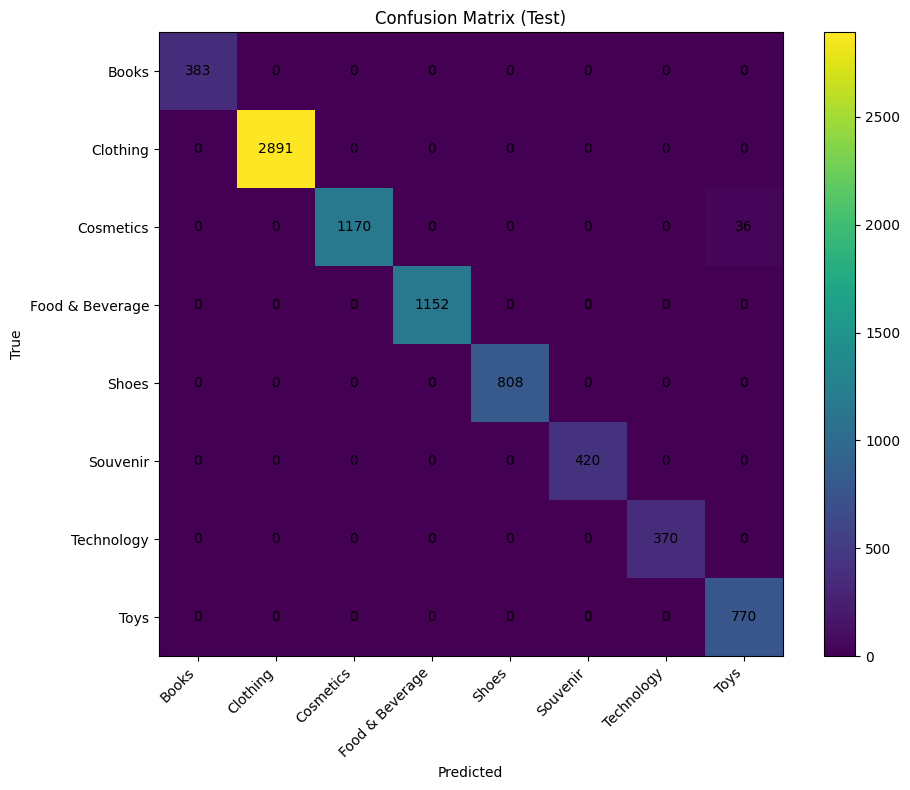

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")

# Hücre içine sayıları yaz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

for name, arr in [("Train", y_train), ("Test", y_test)]:
    counts = np.bincount(arr, minlength=len(le.classes_))
    print(f"\n{name} class distribution:")
    for i, c in enumerate(counts):
        print(f"  {i} ({le.classes_[i]}): {c}")



Train class distribution:
  0 (Books): 1617
  1 (Clothing): 11076
  2 (Cosmetics): 4856
  3 (Food & Beverage): 4740
  4 (Shoes): 3236
  5 (Souvenir): 1580
  6 (Technology): 1629
  7 (Toys): 3266

Test class distribution:
  0 (Books): 383
  1 (Clothing): 2891
  2 (Cosmetics): 1206
  3 (Food & Beverage): 1152
  4 (Shoes): 808
  5 (Souvenir): 420
  6 (Technology): 370
  7 (Toys): 770


In [ ]:
# ===============================
# MODEL VE YARDIMCI NESNELERİ KAYDETME
# ===============================

import joblib
import os

save_dir = "/content/drive/MyDrive/shopping_chatbot_model"
os.makedirs(save_dir, exist_ok=True)

# 1️⃣ Neural Network modeli (Keras)
model_path = os.path.join(save_dir, "category_model.keras")
model.save(model_path)

# 2️⃣ Preprocess pipeline (Scaler + OneHotEncoder)
preprocess_path = os.path.join(save_dir, "preprocess.joblib")
joblib.dump(preprocess, preprocess_path)

# 3️⃣ LabelEncoder (category mapping)
label_encoder_path = os.path.join(save_dir, "label_encoder.joblib")
joblib.dump(le, label_encoder_path)

print("✅ Model kaydedildi:", model_path)
print("✅ Preprocess kaydedildi:", preprocess_path)
print("✅ LabelEncoder kaydedildi:", label_encoder_path)


✅ Model kaydedildi: /content/drive/MyDrive/shopping_chatbot_model/category_model.keras
✅ Preprocess kaydedildi: /content/drive/MyDrive/shopping_chatbot_model/preprocess.joblib
✅ LabelEncoder kaydedildi: /content/drive/MyDrive/shopping_chatbot_model/label_encoder.joblib
